# EDA

In [36]:
!ls /kaggle/input/datasets/yousefmohamed20/oxford-102-flower-dataset/

'102 flower'   README.md


In [37]:
from PIL import Image
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as pghlt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [38]:
from pathlib import Path
import pandas as pd

# базовый путь
base = Path("/kaggle/input/datasets/yousefmohamed20/oxford-102-flower-dataset/102 flower/flowers")

if not base.exists():
    raise FileNotFoundError(f"Папка не найдена: {base}")

splits = ["train", "test", "valid"]

rows = []
for split in splits:
    split_dir = base / split
    if not split_dir.exists():
        print(f"Не найдена папка: {split_dir}")
        continue

    # structure: split / class(1..102) / image
    for file in sorted(split_dir.glob("*/*.*")):
        rows.append({
            "image": str(file),
            "label": int(file.parent.name),  # 1..102
            "split": split
        })

df = pd.DataFrame(rows)

In [39]:
df

,image,label,split
0,/kaggle/input/datasets/yousefmohamed20/oxford-...,1,train
1,/kaggle/input/datasets/yousefmohamed20/oxford-...,1,train
2,/kaggle/input/datasets/yousefmohamed20/oxford-...,1,train
3,/kaggle/input/datasets/yousefmohamed20/oxford-...,1,train
4,/kaggle/input/datasets/yousefmohamed20/oxford-...,1,train
...,...,...,...
8184,/kaggle/input/datasets/yousefmohamed20/oxford-...,99,valid
8185,/kaggle/input/datasets/yousefmohamed20/oxford-...,99,valid
8186,/kaggle/input/datasets/yousefmohamed20/oxford-...,99,valid
8187,/kaggle/input/datasets/yousefmohamed20/oxford-...,99,valid


In [40]:
# 1. Сколько всего классов?


num_classes = df['label'].nunique()
print(f"1. Всего классов: {num_classes}\n")

1. Всего классов: 102



In [41]:
# 2. Размер датасета (train/test/valid)

print("Всего изображений:", len(df))
print("Классов:", df["label"].nunique())
print(df["split"].value_counts())
print(df.head())

Всего изображений: 8189
Классов: 102
split
train    6552
test      819
valid     818
Name: count, dtype: int64
                                               image  label  split
0  /kaggle/input/datasets/yousefmohamed20/oxford-...      1  train
1  /kaggle/input/datasets/yousefmohamed20/oxford-...      1  train
2  /kaggle/input/datasets/yousefmohamed20/oxford-...      1  train
3  /kaggle/input/datasets/yousefmohamed20/oxford-...      1  train
4  /kaggle/input/datasets/yousefmohamed20/oxford-...      1  train


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

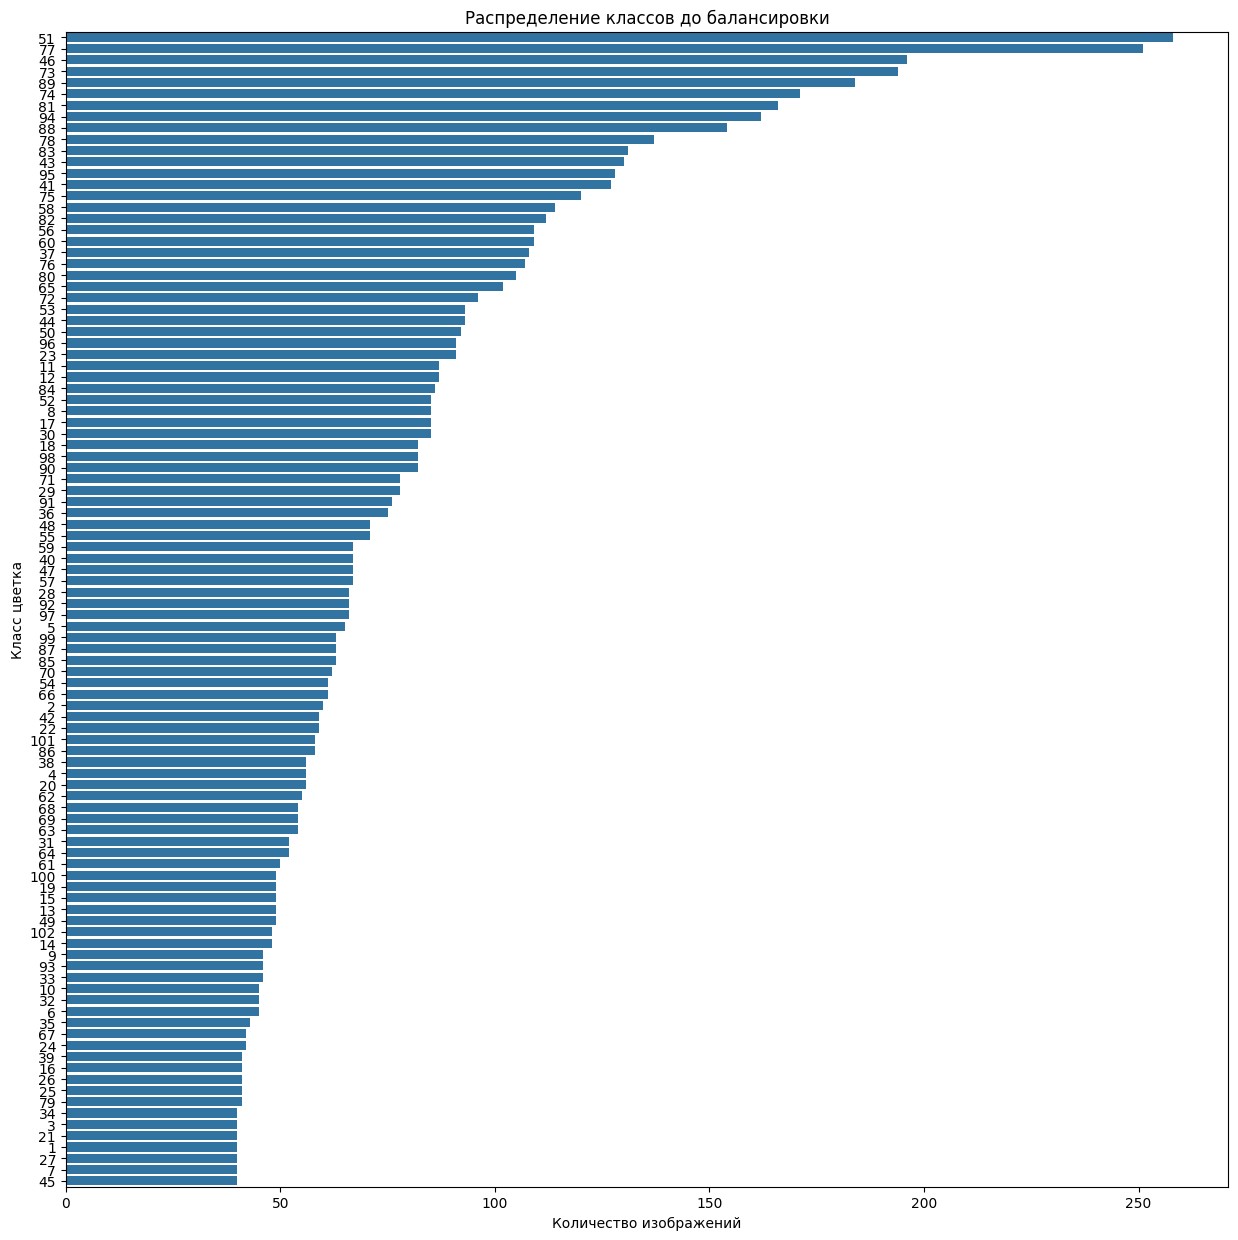

In [43]:
# 3. Распределение классов до балансировки

plt.figure(figsize=(15, 15))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Распределение классов до балансировки')
plt.xlabel('Количество изображений')
plt.ylabel('Класс цветка')
plt.show()

In [44]:
# Проблемы с несбалансированностью классов

train_dist = df[df["split"] == "train"]["label"].value_counts(normalize=True)

print("\nБаланс классов (train):")
print(f"Максимальная доля класса: {train_dist.max():.2f}")
print(f"Минимальная доля класса: {train_dist.min():.2f}")
print(f"Соотношение: {train_dist.max()/train_dist.min():.1f}:1")


Баланс классов (train):
Максимальная доля класса: 0.03
Минимальная доля класса: 0.00
Соотношение: 7.6:1


In [45]:
for split in ["test", "valid"]:
    dist = df[df["split"] == split]["label"].value_counts(normalize=True)
    print(f"\n{split.upper()}: max/min = {dist.max()/dist.min():.1f}:1")


TEST: max/min = 14.0:1

VALID: max/min = 28.0:1


In [46]:
# 5. Разрешение изображений
# Проверим несколько изображений


sample_images = df['image'].sample(10)
resolutions = []
for img_path in sample_images:
    try:
        with Image.open(img_path) as img:
            resolutions.append(img.size)
    except:
        continue

print(f"5. Примеры разрешений изображений: {resolutions[:10]}\n")

5. Примеры разрешений изображений: [(754, 500), (501, 500), (667, 500), (667, 500), (500, 667), (741, 500), (692, 500), (667, 500), (500, 781), (500, 667)]



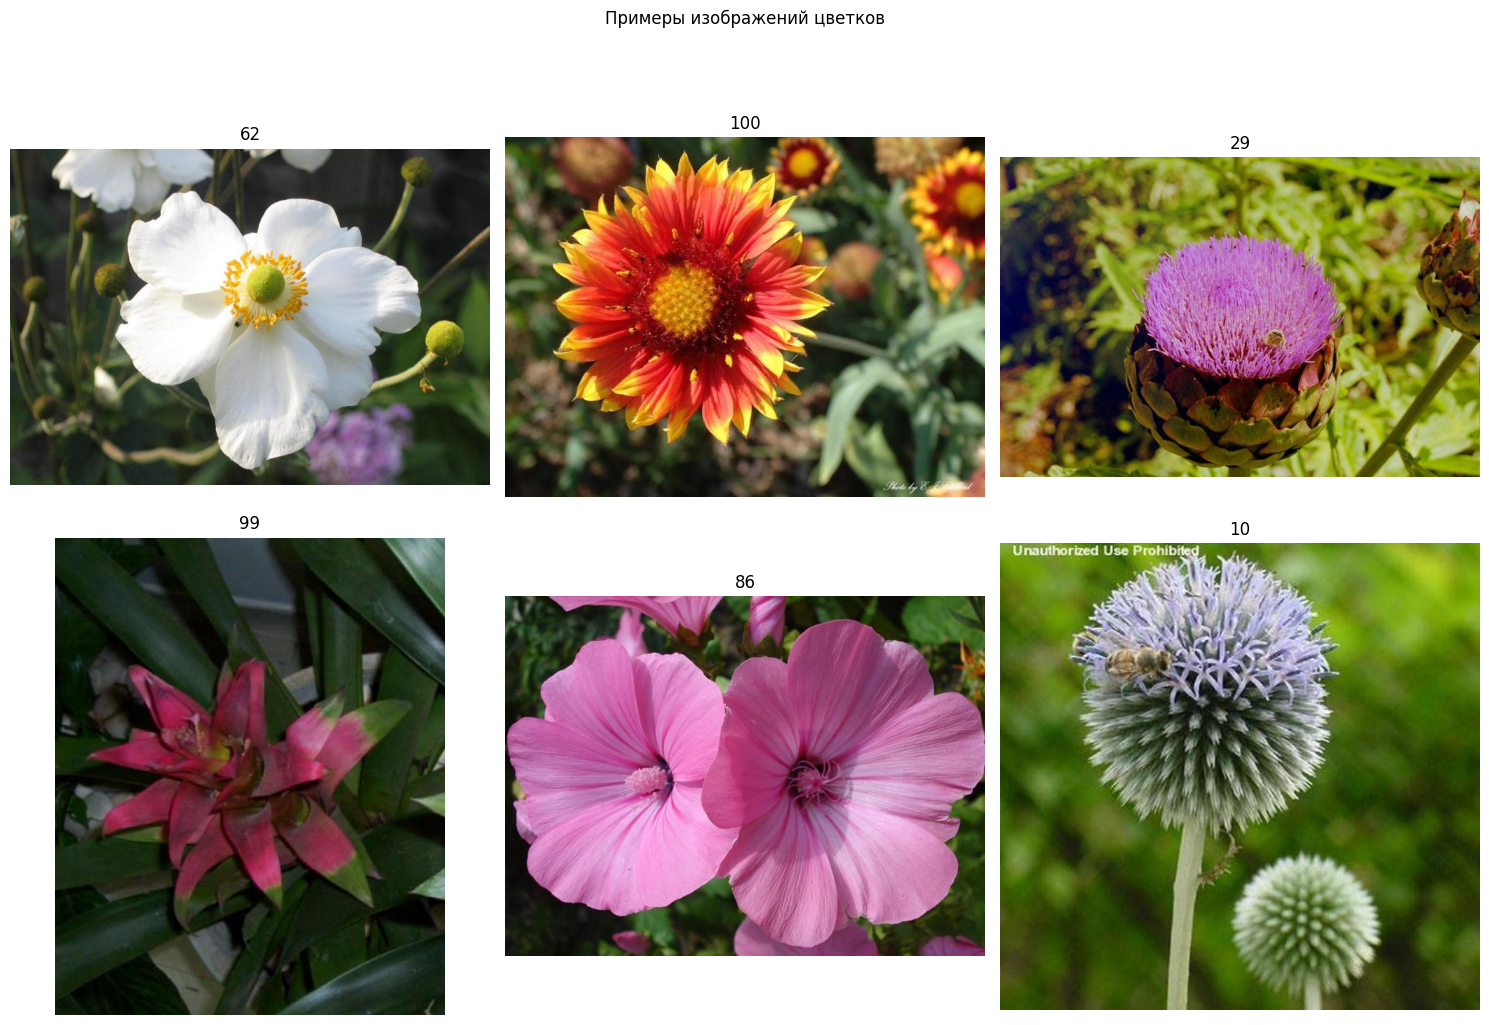

In [47]:
# 6. Анализ специфических особенностей 
# Визуализируем несколько примеров


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (idx, row) in enumerate(df.sample(6).iterrows()):
    ax = axes[i//3, i%3]
    try:
        img = Image.open(row['image'])
        ax.imshow(img)
        ax.set_title(row['label'])
        ax.axis('off')
    except:
        continue
plt.suptitle('Примеры изображений цветков', y=1.02)
plt.tight_layout()
plt.show()

# модель

In [48]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from pathlib import Path
from datasets import Dataset, Image, ClassLabel, DatasetDict
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import json

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.transforms import (
    Compose, RandomResizedCrop, RandomHorizontalFlip, ColorJitter, 
    GaussianBlur, ToTensor, RandomRotation, RandomErasing, 
    RandomPerspective, RandomAffine, Resize, Normalize, CenterCrop
)
from transformers import (
    DeiTImageProcessor, DeiTForImageClassification,
    AutoImageProcessor, AutoModelForImageClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

from sklearn.metrics import (  
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

## Загружаем и обрабатываем данные

In [49]:
from pathlib import Path
import pandas as pd

from datasets import Dataset, Image, ClassLabel, Features, Value

# 1) База датасета (как у тебя реально лежит после kagglehub)
file_names, labels, split_names = [], [], []

for split in ["train", "test", "valid"]:
    split_dir = base / split
    if not split_dir.exists():
        continue

    for file in split_dir.glob("*/*.*"):
        file_names.append(str(file))
        labels.append(file.parent.name)  # Имя папки (номер класса)
        split_names.append(split) # "1".."102"

# 3) DataFrame (добавили split, чтобы не терять информацию о выборке)
df = pd.DataFrame({
    "image": file_names,
    "label": labels,
    "split": split_names  # Теперь колонка 'split' точно будет существовать
})

# ВАЖНО: жестко приводим типы, чтобы не было Arrow cast ошибок
df = df.dropna().copy()
df["image"] = df["image"].astype(str)
df["label"] = df["label"].astype(str)
df["split"] = df["split"].astype(str)
# 4) Список классов
labels_list = sorted(df["label"].unique().tolist(), key=lambda x: int(x))

# 5) HuggingFace Dataset + корректный ClassLabel + Image
class_labels = ClassLabel(names=labels_list)

# 1. Обновляем описание колонок (добавляем split как текстовое поле)
features = Features({
    "image": Image(),
    "label": class_labels,
    "split": Value("string")  # Добавляем описание для новой колонки
})

dataset = Dataset.from_pandas(df, preserve_index=False).cast(features)


Casting the dataset:   0%|          | 0/8189 [00:00<?, ? examples/s]

In [50]:
dataset

Dataset({
    features: ['image', 'label', 'split'],
    num_rows: 8189
})

In [51]:
label2id, id2label = dict(), dict()
for i, label in enumerate(labels_list):
    label2id[label] = i
    id2label[i] = label

In [52]:
# Разделение на train/val/test
train_data = Dataset.from_pandas(df[df["split"] == "train"], preserve_index=False).cast(features)
val_data = Dataset.from_pandas(df[df["split"] == "valid"], preserve_index=False).cast(features)
test_data = Dataset.from_pandas(df[df["split"] == "test"], preserve_index=False).cast(features)


Casting the dataset:   0%|          | 0/6552 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/818 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/819 [00:00<?, ? examples/s]

In [53]:
# Балансировка train выборки

# Рассчитываем веса только по обучающей выборке
train_labels = np.array(train_data["label"], dtype=int)
class_counts = np.bincount(train_labels)
# Добавляем небольшое число (1e-6), чтобы избежать деления на ноль, если какого-то класса нет в train
class_weights = 1. / (class_counts + 1e-6) 
weights = class_weights[train_labels]

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

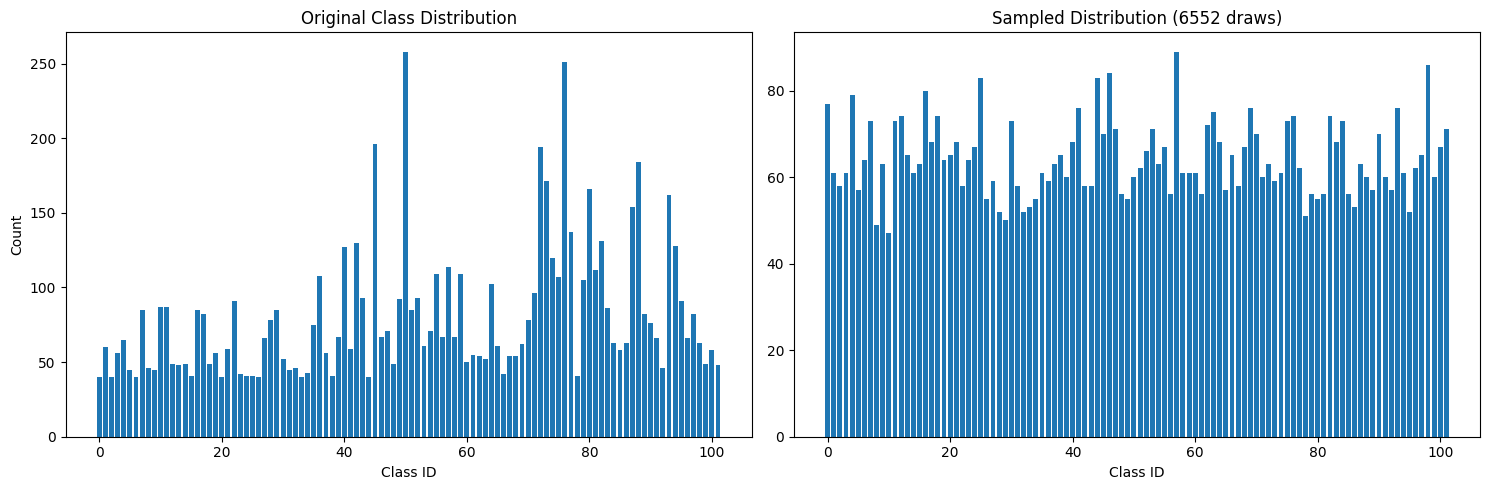


Class Balance Statistics:
Class                      Original   Sampled      Weight
1                                40        77    3.70e-02
2                                60        61    2.04e-02
3                                40        58    2.78e-02
4                                56        61    2.27e-02
5                                65        79    1.85e-02
6                                45        57    2.86e-02
7                                40        64    3.03e-02
8                                85        73    1.43e-02
9                                46        49    2.44e-02
10                               45        63    2.63e-02
11                               87        47    1.47e-02
12                               87        73    1.37e-02
13                               49        74    2.63e-02
14                               48        65    2.27e-02
15                               49        61    2.63e-02
16                               41        63

In [54]:
# проверка балансировки


# Оригинальное распределение
all_label_ids = class_labels.str2int(df["label"])
n_classes = len(labels_list)
original_counts = np.bincount(all_label_ids, minlength=n_classes)

# Генерация выборки из WeightedRandomSampler
num_samples = len(weights)  # или len(train_labels)
sampler_iter = iter(sampler)

sampled_counts = np.zeros(n_classes, dtype=int)
for _ in range(num_samples):
    idx = next(sampler_iter)
    label_id = int(train_labels[idx])
    sampled_counts[label_id] += 1

# Визуализация 
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(range(n_classes), original_counts)
plt.title("Original Class Distribution")
plt.xlabel("Class ID"); plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.bar(range(n_classes), sampled_counts)
plt.title(f"Sampled Distribution ({num_samples} draws)")
plt.xlabel("Class ID")

plt.tight_layout()
plt.show()

# Таблица статистики
print("\nClass Balance Statistics:")
print(f"{'Class':<25}{'Original':>10}{'Sampled':>10}{'Weight':>12}")
for i in range(n_classes):
    print(f"{class_labels.names[i]:<25}{original_counts[i]:>10}{sampled_counts[i]:>10}{class_weights[i]:>12.2e}")


In [55]:
# Модель и процессор

model_name = "facebook/deit-tiny-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]
normalize = Normalize(mean=image_mean, std=image_std)


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [56]:
def train_transform(example):
    example["pixel_values"] = [train_tfms(img.convert("RGB")) for img in example["image"]]
    return example

def val_transform(example):
    example["pixel_values"] = [val_tfms(img.convert("RGB")) for img in example["image"]]
    return example

In [57]:
train_data.set_transform(train_transform)
val_data.set_transform(val_transform)
test_data.set_transform(val_transform)

In [58]:
# Создание батчей

def collate_fn(examples):
    pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
    labels = torch.tensor([ex["label"] for ex in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [59]:
# Аугментации

train_tfms = Compose([
    # Берем случайный фрагмент, но не слишком маленький (минимум 80% площади)
    RandomResizedCrop(size, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    # Отражение — самая безопасная аугментация для цветов
    RandomHorizontalFlip(p=0.5),
    
    # Легкое изменение яркости и контраста. 
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.01),
    ToTensor(),
    normalize
])

val_tfms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize
])

## Сбор модели

In [60]:
# Модель

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at facebook/deit-tiny-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([102, 192]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([102]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [61]:
# Аргументы модели
training_args = TrainingArguments(
    output_dir="flower_deit",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=15,
    learning_rate=5e-5,
    weight_decay=0.02,
    warmup_steps=200,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False, 
    dataloader_drop_last=True,
    dataloader_pin_memory=True,
    dataloader_num_workers=2
)

## Создание и обучение Trainer

In [62]:
# Кастомный Trainer с семплером

class CustomTrainer(Trainer):
    def get_train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=collate_fn,
            num_workers=2,
            pin_memory=True,
            drop_last=True
        )

In [63]:
# Инициализация Trainer'а

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=None,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3,
        early_stopping_threshold=0.001
    )]
)

In [64]:
# Обучение

trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,2.840206
2,No log,1.176904
3,2.473000,0.600315
4,2.473000,0.346946
5,0.301200,0.241652
6,0.301200,0.173565
7,0.301200,0.155530
8,0.055100,0.121365
9,0.055100,0.107886
10,0.018200,0.103099


TrainOutput(global_step=3060, training_loss=0.4675263899019341, metrics={'train_runtime': 771.357, 'train_samples_per_second': 127.412, 'train_steps_per_second': 3.967, 'total_flos': 4.903104600421171e+17, 'train_loss': 0.4675263899019341, 'epoch': 15.0})

## Сохранение модели

In [67]:
import os
import json

# Путь для сохранения модели в директории output
save_path = "/kaggle/working/deit_model_Flowers"  # Путь для сохранения в директории, которая доступна для вывода

# 1. Сохраняем модель и процессор
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

# 2. Сохраняем метаданные (для удобства)
metadata = {
    "id2label": id2label,
    "label2id": label2id,
    "class_names": labels_list,
    "image_size": size
}

# Сохраняем метаданные в JSON файл
metadata_path = os.path.join(save_path, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Модель и метаданные сохранены в {save_path}")


Модель и метаданные сохранены в /kaggle/working/deit_model_Flowers


## Загрузка модели

In [69]:
# Путь
model_path = "/kaggle/working/deit_model_Flowers"

# Грузим модель и процессор
model = AutoModelForImageClassification.from_pretrained(model_path)
processor = AutoImageProcessor.from_pretrained(model_path)

# Загружаем метаданные (классы, размер и т.д.)
with open(f"{model_path}/metadata.json") as f:
    meta = json.load(f)
id2label = meta["id2label"]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Оценка модели

In [70]:
test_loader = DataLoader(
    test_data,
    batch_size=32,  
    shuffle=False,
    collate_fn=collate_fn, 
    num_workers=2,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for batch in tqdm(test_loader):
        imgs  = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(imgs).logits
        preds  = torch.argmax(logits, dim=-1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

100%|██████████| 26/26 [00:06<00:00,  4.20it/s]


In [71]:
# Метрики

acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy   : {acc:.4f}")
print(f"Macro-F1   : {f1:.4f}\n")

Accuracy   : 0.9658
Macro-F1   : 0.9605



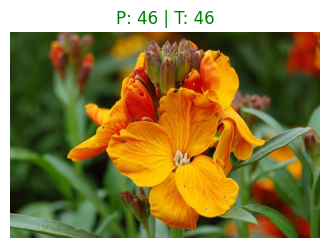

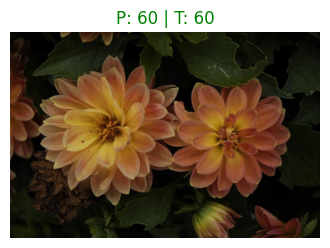

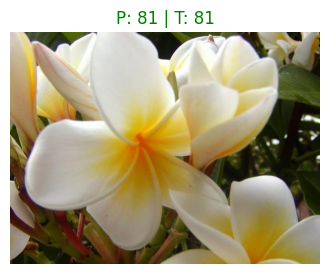

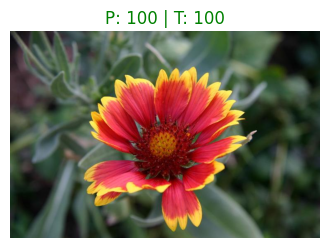

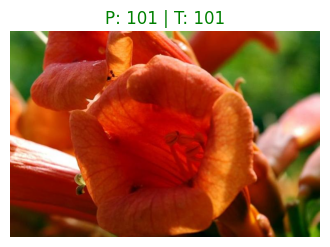

In [72]:
import random

# Выбираем 5 случайных индексов из тестовой выборки
random_indices = random.sample(range(len(test_data)), 5)

for idx in random_indices:
    # Получаем путь к файлу и истинную метку
    # В вашем dataset объекты хранятся как {'image': <PIL Image>, 'label': <int_index>}
    sample = test_data[idx]
    image = sample['image']
    true_label_idx = sample['label']
    true_label = id2label[str(true_label_idx)]
    
    # Для изуализации через функцию выше, если есть объект PIL Image:
    inputs = processor(images=image.convert("RGB"), return_tensors="pt")
    pixel_values = inputs.pixel_values.to(device)
    
    with torch.no_grad():
        logits = model(pixel_values).logits
        pred_idx = torch.argmax(logits, dim=-1).item()
        pred_label = id2label[str(pred_idx)]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P: {pred_label} | T: {true_label}", color=color)
    plt.axis('off')
    plt.show()

In [73]:
# Отчёт по классам

print(classification_report(y_true, y_pred, target_names=labels_list))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         2
           4       0.60      0.50      0.55         6
           5       1.00      1.00      1.00         4
           6       1.00      0.67      0.80         9
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00        10
           9       0.67      1.00      0.80         2
          10       1.00      1.00      1.00         3
          11       0.90      1.00      0.95         9
          12       0.89      0.89      0.89         9
          13       1.00      1.00      1.00         6
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         4
          16       1.00      1.00      1.00         3
          17       1.00      1.00      1.00         9
          18       1.00    

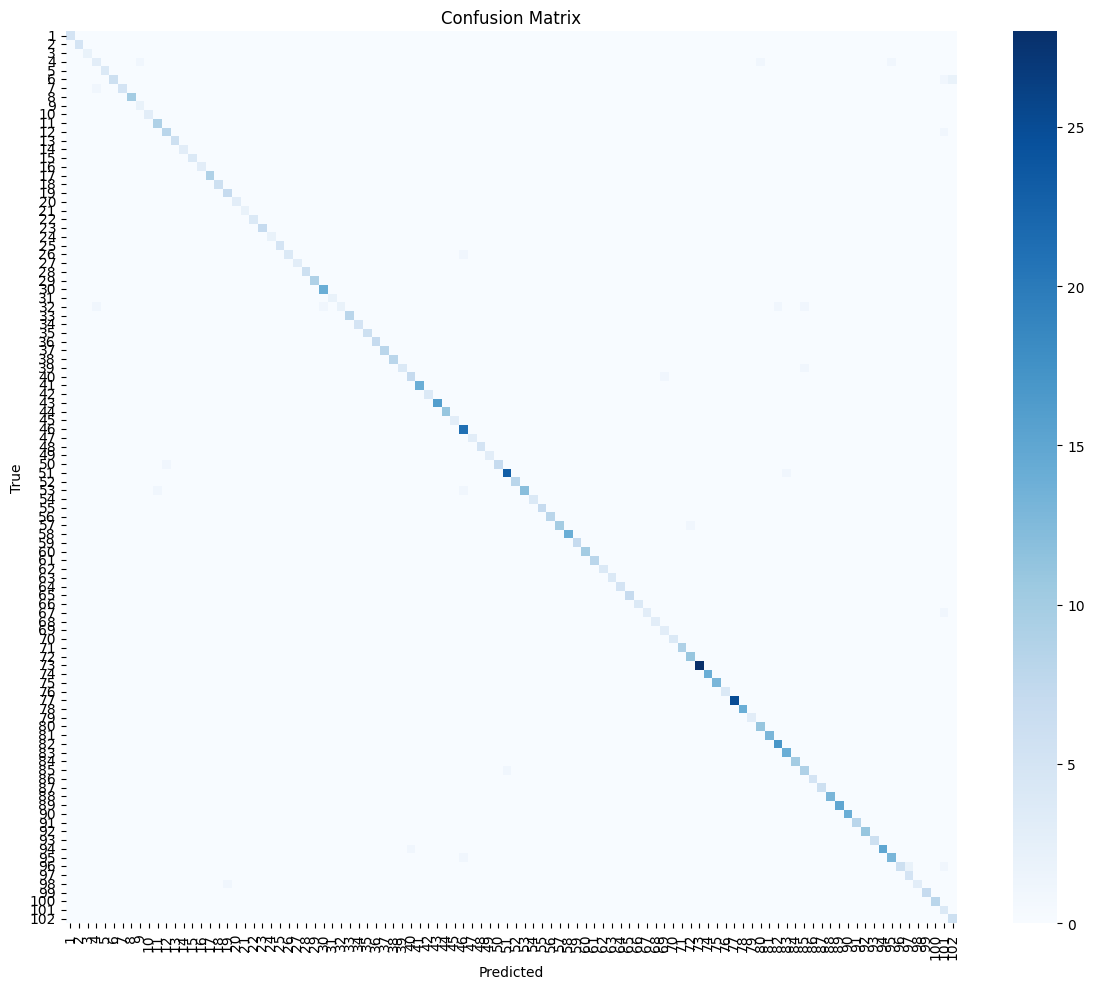

In [74]:
# Матрица ошибок

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            cmap="Blues",
            fmt="d",
            xticklabels=labels_list,
            yticklabels=labels_list,
            annot=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()